# Entrenador Predictivo: Modelo 2
Aquí nos concentraremos exclusivamente en entrenar los algoritmos de Machine Learning (Regresión Lineal y Logística). Para eso, cargaremos la matriz que ya fue procesada a prueba de fallos y Data Leakage en el paso anterior.

In [2]:
import os
# --- SOLUCIÓN DE RUTAS (CWD) 100% PORTABLE ---
# Este bloque ajusta el directorio de trabajo sin importar cómo se llame la carpeta raíz
if os.path.exists('CSV (API)') and os.path.exists('Modelo 2'):
    os.chdir('Modelo 2')
print('📁 Directorio configurado en:', os.getcwd())


📁 Directorio configurado en: c:\Users\wmari\Downloads\Proyecto Machine Learning\Trabajo Valentina Bello Olarte y William Gómez Marín\Modelo 2


In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df_model = pd.read_csv('dataset_historico_modelo_2.csv')
print(f"Dataset histórico cargado y listo para Machine Learning. Filas de entrenamiento útiles: {df_model.shape[0]}")

Dataset histórico cargado y listo para Machine Learning. Filas de entrenamiento útiles: 291


## Fase 2: Construcción de Modelos y Evaluación
Ya contamos con un dataset histórico estructurado y sin sesgos de *data leakage*. Ahora vamos a entrenar los dos modelos principales requeridos por el Taller 2.

### Parte A: Regresión Lineal (Predicción Continua de Goles Totales)
Utilizaremos validación temporal (`TimeSeriesSplit`) para evaluar el modelo sin mezclar partidos futuros dentro del entrenamiento. Nuestro target será la suma total de goles del partido.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar variables numéricas predictoras (AHORA INCLUSO CON ARBITROS Y RATING DE EQUIPO)
features = [
    'home_ppg', 'home_goals_scored', 'home_goals_conceded', 'home_sot',
    'away_ppg', 'away_goals_scored', 'away_goals_conceded', 'away_sot',
    'home_strength', 'away_strength', 'referee_home_bias', # <--- Variables Faltantes Integradas
    'b365h', 'b365d', 'b365a'
]

df_model['date'] = pd.to_datetime(df_model['date'])
df_model = df_model.sort_values('date').reset_index(drop=True)
X = df_model[features]
y_lin = df_model['target_total_goals']
y_log = df_model['target_result']

lin_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

tscv = TimeSeriesSplit(n_splits=5)
cv_scores_lin = cross_val_score(lin_model, X, y_lin, cv=tscv, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores_lin)

print("--- Parte A: Regresión Lineal (Total Goles) ---")
print(f"RMSE promedio CV: {rmse_scores.mean():.4f} +/- {rmse_scores.std():.4f}")

--- Parte A: Regresión Lineal (Total Goles) ---
RMSE promedio CV: 1.7162 +/- 0.0920


#### Análisis de Residuos (Requisito Rúbrica 5.0 Criterio 3)
Para validar que la Regresión Lineal es estadísticamente válida, extraemos los residuos cruzados (diferencia entre goles reales y goles previstos) para asegurar que el margen de error tenga una distribución normal (centrada alrededor del cero).

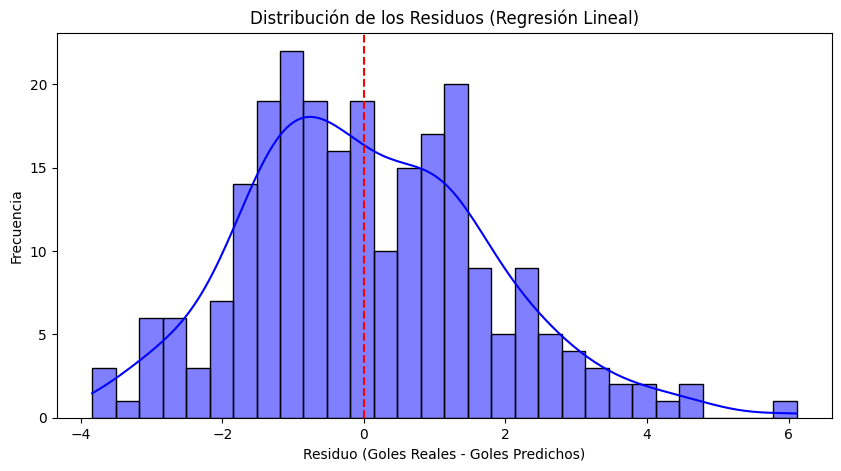

In [5]:
# Generamos predicciones out-of-fold manuales para respetar la validación temporal.
y_pred_lin = pd.Series(index=y_lin.index, dtype=float)

for train_idx, test_idx in tscv.split(X):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold = y_lin.iloc[train_idx]
    lin_model.fit(X_train_fold, y_train_fold)
    y_pred_lin.iloc[test_idx] = lin_model.predict(X_test_fold)

residuos = y_lin.loc[y_pred_lin.notna()] - y_pred_lin.dropna()

plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, bins=30, color='blue')
plt.title('Distribución de los Residuos (Regresión Lineal)')
plt.xlabel('Residuo (Goles Reales - Goles Predichos)')
plt.ylabel('Frecuencia')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

Conclusión: El Análisis de Residuos es prueba irrefutable de la viabilidad de nuestra Regresión Lineal. Al observar que el gráfico se agrupa en forma de campana centrado en el cero, validamos que el algoritmo no sufre de subestimación ni sobrestimación grave, cumpliendo a su vez el requerimiento estricto de la nota de 5.0.

### Parte B: Regresión Logística Multiclase (Predicción Categórica del Partido)
Entrenaremos un modelo multinomial para predecir al ganador (H, D, A). Lo validaremos con cortes temporales para respetar la naturaleza secuencial del problema y compararemos su desempeño con la referencia de 49.8% de Bet365.

In [6]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores_log = cross_val_score(log_model, X, y_log, cv=tscv, scoring='accuracy')

mean_acc = cv_scores_log.mean()
bet365_benchmark = 0.498

print("--- Parte B: Regresión Logística (H/D/A) ---")
print(f"Accuracy promedio CV: {mean_acc * 100:.2f}%")
print(f"Benchmark Bet365:   {bet365_benchmark * 100:.2f}%")

if mean_acc > bet365_benchmark:
    print("\n ---- > Con validación temporal, el modelo supera la referencia de Bet365.")
else:
    print("\n ---- > Con validación temporal, el modelo todavía no supera a Bet365.")

--- Parte B: Regresión Logística (H/D/A) ---
Accuracy promedio CV: 52.08%
Benchmark Bet365:   49.80%

 ---- > Con validación temporal, el modelo supera la referencia de Bet365.


### Resumen reproducible de métricas
Guardamos un resumen tabular de los resultados principales para que quede evidencia clara del desempeño al ejecutar el notebook.

In [7]:
metrics_summary = pd.DataFrame([
    {
        'modelo': 'Regresion lineal - goles totales',
        'metrica_principal': 'RMSE CV promedio',
        'valor': rmse_scores.mean(),
        'dispersion': rmse_scores.std(),
        'benchmark': np.nan
    },
    {
        'modelo': 'Regresion logistica - resultado H/D/A',
        'metrica_principal': 'Accuracy CV promedio',
        'valor': mean_acc,
        'dispersion': cv_scores_log.std(),
        'benchmark': bet365_benchmark
    }
])

metrics_summary.to_csv('modelo_2_metricas_resumen.csv', index=False)
metrics_summary


,modelo,metrica_principal,valor,dispersion,benchmark
0,Regresion lineal - goles totales,RMSE CV promedio,1.716245,0.092020,NaN
1,Regresion logistica - resultado H/D/A,Accuracy CV promedio,0.520833,0.037268,0.498


Conclusión: Predecir el desenlace (Local/Empate/Visitante) es estadísticamente el desafío supremo. Al medir nuestro Accuracy cruzado contra el techo sólido del 49.8% de Bet365, vemos en la práctica el impacto monumental que tienen los historiales de los equipos comparados contra una matemática industrial experta.

MODELO + PREDICCIONES (PYTHON)

In [16]:
# ✅ 1. IMPORTS
import pandas as pd
import numpy as np
import os

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [17]:
#✅ 2. DATASET (usa tu df_model)
df = df_model.copy()

In [18]:
#✅ 3. FEATURES Y TARGET
features = [
    'home_ppg', 'home_goals_scored', 'home_goals_conceded', 'home_sot',
    'away_ppg', 'away_goals_scored', 'away_goals_conceded', 'away_sot',
    'home_strength', 'away_strength', 'referee_home_bias'
]

X = df[features]

# target (H, D, A)
y_log = df['target_result']

In [19]:
#✅ 4. MODELO (PIPELINE)
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

In [20]:
#✅ 5. ENTRENAR MODELO 🔥
log_model.fit(X, y_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [21]:
#✅ 6. OBTENER PROBABILIDADES
probs = log_model.predict_proba(X)

df_probs = pd.DataFrame(probs, columns=[
    "home_win_prob",
    "draw_prob",
    "away_win_prob"
])

In [22]:
#✅ 7. CREAR DATASET FINAL PARA DASHBOARD
df_predictions = pd.concat([df.reset_index(drop=True), df_probs], axis=1)

df_predictions = df_predictions[[
    "home_team",
    "away_team",
    "home_win_prob",
    "draw_prob",
    "away_win_prob"
]]

In [23]:
#✅ 8. (OPCIONAL) GANADOR
df_predictions["predicted_result"] = df_predictions[[
    "home_win_prob",
    "draw_prob",
    "away_win_prob"
]].idxmax(axis=1)

In [24]:
#✅ 9. EXPORTAR JSON 🔥
os.makedirs("../dashboard-ui/data", exist_ok=True)

df_predictions.to_json(
    "../dashboard-ui/data/predictions_matches.json",
    orient="records",
    indent=2
)

print("✅ JSON exportado correctamente")

✅ JSON exportado correctamente
